# 🏆 Predicción: España vs Arabia Saudí - Mundial 2026
### Grupo H - 21 junio | Atlanta 🇺🇸
### Resultado real: España 4-0 Arabia Saudí ✅

¿Qué hubiera predicho nuestro modelo? Vamos a comprobarlo.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import poisson
import warnings
warnings.filterwarnings('ignore')

plt.style.use('dark_background')
np.random.seed(42)

## 📥 Carga de datos: +47,000 partidos internacionales

In [2]:
# Dataset público: resultados internacionales desde 1872
url = 'https://raw.githubusercontent.com/martj42/international_results/master/results.csv'
df = pd.read_csv(url)
df['date'] = pd.to_datetime(df['date'])

# Eliminamos partidos sin resultado (programados pero no jugados)
df = df.dropna(subset=['home_score', 'away_score'])

print(f'📊 Dataset cargado: {len(df):,} partidos')
print(f'📅 Desde {df["date"].min().strftime("%Y")} hasta {df["date"].max().strftime("%Y")}')
print(f'🏟️ Torneos: {df["tournament"].nunique()}')
df.head()

📊 Dataset cargado: 49,459 partidos
📅 Desde 1872 hasta 2026
🏟️ Torneos: 200


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


## 🇪🇸🇸🇦 Head-to-Head histórico

In [3]:
team_a = 'Spain'
team_b = 'Saudi Arabia'

# Filtrar partidos entre ambos equipos
h2h = df[((df['home_team'] == team_a) & (df['away_team'] == team_b)) |
          ((df['home_team'] == team_b) & (df['away_team'] == team_a))].copy()

# Normalizar goles
h2h['spain_goals'] = np.where(h2h['home_team'] == team_a, h2h['home_score'], h2h['away_score'])
h2h['saudi_goals'] = np.where(h2h['home_team'] == team_b, h2h['home_score'], h2h['away_score'])
h2h['result'] = np.where(h2h['spain_goals'] > h2h['saudi_goals'], 'España',
                 np.where(h2h['spain_goals'] < h2h['saudi_goals'], 'Arabia Saudí', 'Empate'))

print(f'⚔️ HISTORIAL DIRECTO: {len(h2h)} partidos')
print('=' * 50)
print(h2h['result'].value_counts().to_string())
print(f'\n⚽ Media goles España: {h2h["spain_goals"].mean():.2f}')
print(f'⚽ Media goles Arabia Saudí: {h2h["saudi_goals"].mean():.2f}')
print()
print(h2h[['date', 'home_team', 'home_score', 'away_score', 'away_team', 'tournament']].to_string(index=False))

⚔️ HISTORIAL DIRECTO: 4 partidos
result
España    4

⚽ Media goles España: 3.25
⚽ Media goles Arabia Saudí: 0.50

      date    home_team  home_score  away_score    away_team     tournament
2006-06-23 Saudi Arabia         0.0         1.0        Spain FIFA World Cup
2010-05-29        Spain         3.0         2.0 Saudi Arabia       Friendly
2012-09-07        Spain         5.0         0.0 Saudi Arabia       Friendly
2026-06-21        Spain         4.0         0.0 Saudi Arabia FIFA World Cup


## 📈 Forma reciente (últimos 20 partidos de cada selección)

In [4]:
def get_team_stats(df, team, n_matches=20):
    """Obtiene estadísticas de los últimos N partidos de un equipo."""
    team_matches = df[(df['home_team'] == team) | (df['away_team'] == team)].copy()
    team_matches = team_matches.sort_values('date').tail(n_matches)
    
    goals_scored = np.where(team_matches['home_team'] == team,
                            team_matches['home_score'], team_matches['away_score'])
    goals_conceded = np.where(team_matches['home_team'] == team,
                              team_matches['away_score'], team_matches['home_score'])
    
    wins = np.sum(goals_scored > goals_conceded)
    draws = np.sum(goals_scored == goals_conceded)
    losses = np.sum(goals_scored < goals_conceded)
    
    return {
        'equipo': team,
        'partidos': len(team_matches),
        'victorias': int(wins),
        'empates': int(draws),
        'derrotas': int(losses),
        'goles_favor': float(goals_scored.mean()),
        'goles_contra': float(goals_conceded.mean()),
        'win_rate': float(wins / len(team_matches))
    }

stats_espana = get_team_stats(df, team_a, 20)
stats_saudi = get_team_stats(df, team_b, 20)

forma = pd.DataFrame([stats_espana, stats_saudi])
print('📋 FORMA RECIENTE (últimos 20 partidos en el dataset)')
print('=' * 65)
print(forma.to_string(index=False))

📋 FORMA RECIENTE (últimos 20 partidos en el dataset)
      equipo  partidos  victorias  empates  derrotas  goles_favor  goles_contra  win_rate
       Spain        20         13        7         0         2.65          0.90      0.65
Saudi Arabia        20          7        5         8         1.05          1.35      0.35


## 🧮 Cálculo de fuerza ofensiva/defensiva (método Dixon-Coles simplificado)

In [5]:
# Usamos partidos recientes (últimos 4 años) para calcular fuerzas relativas
recent = df[df['date'] >= '2022-01-01'].copy()

# Media global de goles
avg_home_goals = recent['home_score'].mean()
avg_away_goals = recent['away_score'].mean()
avg_total = (avg_home_goals + avg_away_goals) / 2

print(f'📊 ESTADÍSTICAS GLOBALES (partidos desde 2022)')
print(f'   Partidos analizados: {len(recent):,}')
print(f'   Media goles local: {avg_home_goals:.2f}')
print(f'   Media goles visitante: {avg_away_goals:.2f}')
print(f'   Media total por equipo: {avg_total:.2f}')

def attack_strength(df, team):
    """Fuerza ofensiva = goles marcados / media global."""
    home_goals = df[df['home_team'] == team]['home_score'].sum()
    away_goals = df[df['away_team'] == team]['away_score'].sum()
    home_matches = len(df[df['home_team'] == team])
    away_matches = len(df[df['away_team'] == team])
    total_matches = home_matches + away_matches
    if total_matches == 0:
        return 1.0
    avg_scored = (home_goals + away_goals) / total_matches
    return avg_scored / avg_total

def defense_strength(df, team):
    """Fuerza defensiva = goles recibidos / media global."""
    home_conceded = df[df['home_team'] == team]['away_score'].sum()
    away_conceded = df[df['away_team'] == team]['home_score'].sum()
    home_matches = len(df[df['home_team'] == team])
    away_matches = len(df[df['away_team'] == team])
    total_matches = home_matches + away_matches
    if total_matches == 0:
        return 1.0
    avg_conceded = (home_conceded + away_conceded) / total_matches
    return avg_conceded / avg_total

atk_spain = attack_strength(recent, team_a)
def_spain = defense_strength(recent, team_a)
atk_saudi = attack_strength(recent, team_b)
def_saudi = defense_strength(recent, team_b)

print(f'\n🇪🇸 ESPAÑA:')
print(f'   Fuerza ofensiva: {atk_spain:.3f} (>1.0 = mejor que la media)')
print(f'   Fuerza defensiva: {def_spain:.3f} (<1.0 = mejor que la media)')
print(f'\n🇸🇦 ARABIA SAUDÍ:')
print(f'   Fuerza ofensiva: {atk_saudi:.3f}')
print(f'   Fuerza defensiva: {def_saudi:.3f}')

📊 ESTADÍSTICAS GLOBALES (partidos desde 2022)
   Partidos analizados: 4,622
   Media goles local: 1.61
   Media goles visitante: 1.11
   Media total por equipo: 1.36

🇪🇸 ESPAÑA:
   Fuerza ofensiva: 1.824 (>1.0 = mejor que la media)
   Fuerza defensiva: 0.577 (<1.0 = mejor que la media)

🇸🇦 ARABIA SAUDÍ:
   Fuerza ofensiva: 0.764
   Fuerza defensiva: 0.764


## ⚡ Modelo de Poisson: goles esperados (Lambda)

In [6]:
# Lambda = ataque_propio * defensa_rival * media_goles
lambda_spain = atk_spain * def_saudi * avg_total
lambda_saudi = atk_saudi * def_spain * avg_total

# Ajuste por H2H (basado en datos)
h2h_spain_avg = h2h['spain_goals'].mean()
h2h_saudi_avg = h2h['saudi_goals'].mean()

# Combinamos: 70% modelo general + 30% H2H
lambda_spain_final = 0.7 * lambda_spain + 0.3 * h2h_spain_avg
lambda_saudi_final = 0.7 * lambda_saudi + 0.3 * h2h_saudi_avg

print('⚡ GOLES ESPERADOS (Lambda de Poisson)')
print('=' * 50)
print(f'\n   Modelo base (ataque x defensa rival x media):')
print(f'   España: λ = {lambda_spain:.3f}')
print(f'   Arabia Saudí: λ = {lambda_saudi:.3f}')
print(f'\n   H2H histórico (media de goles en enfrentamientos):')
print(f'   España: {h2h_spain_avg:.3f} goles/partido')
print(f'   Arabia Saudí: {h2h_saudi_avg:.3f} goles/partido')
print(f'\n   🎯 Lambda FINAL (70% modelo + 30% H2H):')
print(f'   España: λ = {lambda_spain_final:.3f}')
print(f'   Arabia Saudí: λ = {lambda_saudi_final:.3f}')

⚡ GOLES ESPERADOS (Lambda de Poisson)

   Modelo base (ataque x defensa rival x media):
   España: λ = 1.896
   Arabia Saudí: λ = 0.600

   H2H histórico (media de goles en enfrentamientos):
   España: 3.250 goles/partido
   Arabia Saudí: 0.500 goles/partido

   🎯 Lambda FINAL (70% modelo + 30% H2H):
   España: λ = 2.302
   Arabia Saudí: λ = 0.570


## 🎲 Simulación de Monte Carlo: 100,000 partidos

In [7]:
n_simulaciones = 100_000

goles_espana_sim = np.random.poisson(lambda_spain_final, n_simulaciones)
goles_saudi_sim = np.random.poisson(lambda_saudi_final, n_simulaciones)

victorias_espana = np.sum(goles_espana_sim > goles_saudi_sim)
empates = np.sum(goles_espana_sim == goles_saudi_sim)
victorias_saudi = np.sum(goles_espana_sim < goles_saudi_sim)

prob_espana = victorias_espana / n_simulaciones * 100
prob_empate = empates / n_simulaciones * 100
prob_saudi = victorias_saudi / n_simulaciones * 100

print('🎲 SIMULACIÓN MONTE CARLO (100,000 partidos)')
print('=' * 50)
print(f'   🇪🇸 Victoria España:       {prob_espana:.1f}%')
print(f'   🤝 Empate:                {prob_empate:.1f}%')
print(f'   🇸🇦 Victoria Arabia Saudí: {prob_saudi:.1f}%')
print(f'\n   📊 Media goles España:       {goles_espana_sim.mean():.2f}')
print(f'   📊 Media goles Arabia Saudí: {goles_saudi_sim.mean():.2f}')

🎲 SIMULACIÓN MONTE CARLO (100,000 partidos)
   🇪🇸 Victoria España:       76.8%
   🤝 Empate:                15.8%
   🇸🇦 Victoria Arabia Saudí: 7.4%

   📊 Media goles España:       2.31
   📊 Media goles Arabia Saudí: 0.57


In [8]:
# === MARCADORES MÁS PROBABLES ===

max_goles = 7
matriz_prob = np.zeros((max_goles, max_goles))

for i in range(max_goles):
    for j in range(max_goles):
        matriz_prob[i][j] = poisson.pmf(i, lambda_spain_final) * poisson.pmf(j, lambda_saudi_final)

resultados = []
for i in range(max_goles):
    for j in range(max_goles):
        resultados.append((i, j, matriz_prob[i][j] * 100))

resultados.sort(key=lambda x: x[2], reverse=True)

print('🏆 TOP 10 RESULTADOS MÁS PROBABLES')
print('=' * 50)
for idx, (ge, gs, prob) in enumerate(resultados[:10], 1):
    emoji = '🇪🇸' if ge > gs else ('🇸🇦' if gs > ge else '🤝')
    print(f'  {idx:>2}. España {ge} - {gs} Arabia Saudí  ({prob:>5.1f}%) {emoji}')

# Probabilidad acumulada de que España gane por 4+ goles
prob_4_plus = sum(p for ge, gs, p in resultados if ge - gs >= 4)
print(f'\n🎯 PREDICCIÓN: España {resultados[0][0]} - {resultados[0][1]} Arabia Saudí')
print(f'\n📌 Prob. de que España gane por 4+ goles (como pasó): {prob_4_plus:.1f}%')

🏆 TOP 10 RESULTADOS MÁS PROBABLES
   1. España 2 - 0 Arabia Saudí  ( 15.0%) 🇪🇸
   2. España 1 - 0 Arabia Saudí  ( 13.0%) 🇪🇸
   3. España 3 - 0 Arabia Saudí  ( 11.5%) 🇪🇸
   4. España 2 - 1 Arabia Saudí  (  8.5%) 🇪🇸
   5. España 1 - 1 Arabia Saudí  (  7.4%) 🤝
   6. España 4 - 0 Arabia Saudí  (  6.6%) 🇪🇸
   7. España 3 - 1 Arabia Saudí  (  6.6%) 🇪🇸
   8. España 0 - 0 Arabia Saudí  (  5.7%) 🤝
   9. España 4 - 1 Arabia Saudí  (  3.8%) 🇪🇸
  10. España 0 - 1 Arabia Saudí  (  3.2%) 🇸🇦

🎯 PREDICCIÓN: España 2 - 0 Arabia Saudí

📌 Prob. de que España gane por 4+ goles (como pasó): 13.4%


## 📈 Visualizaciones

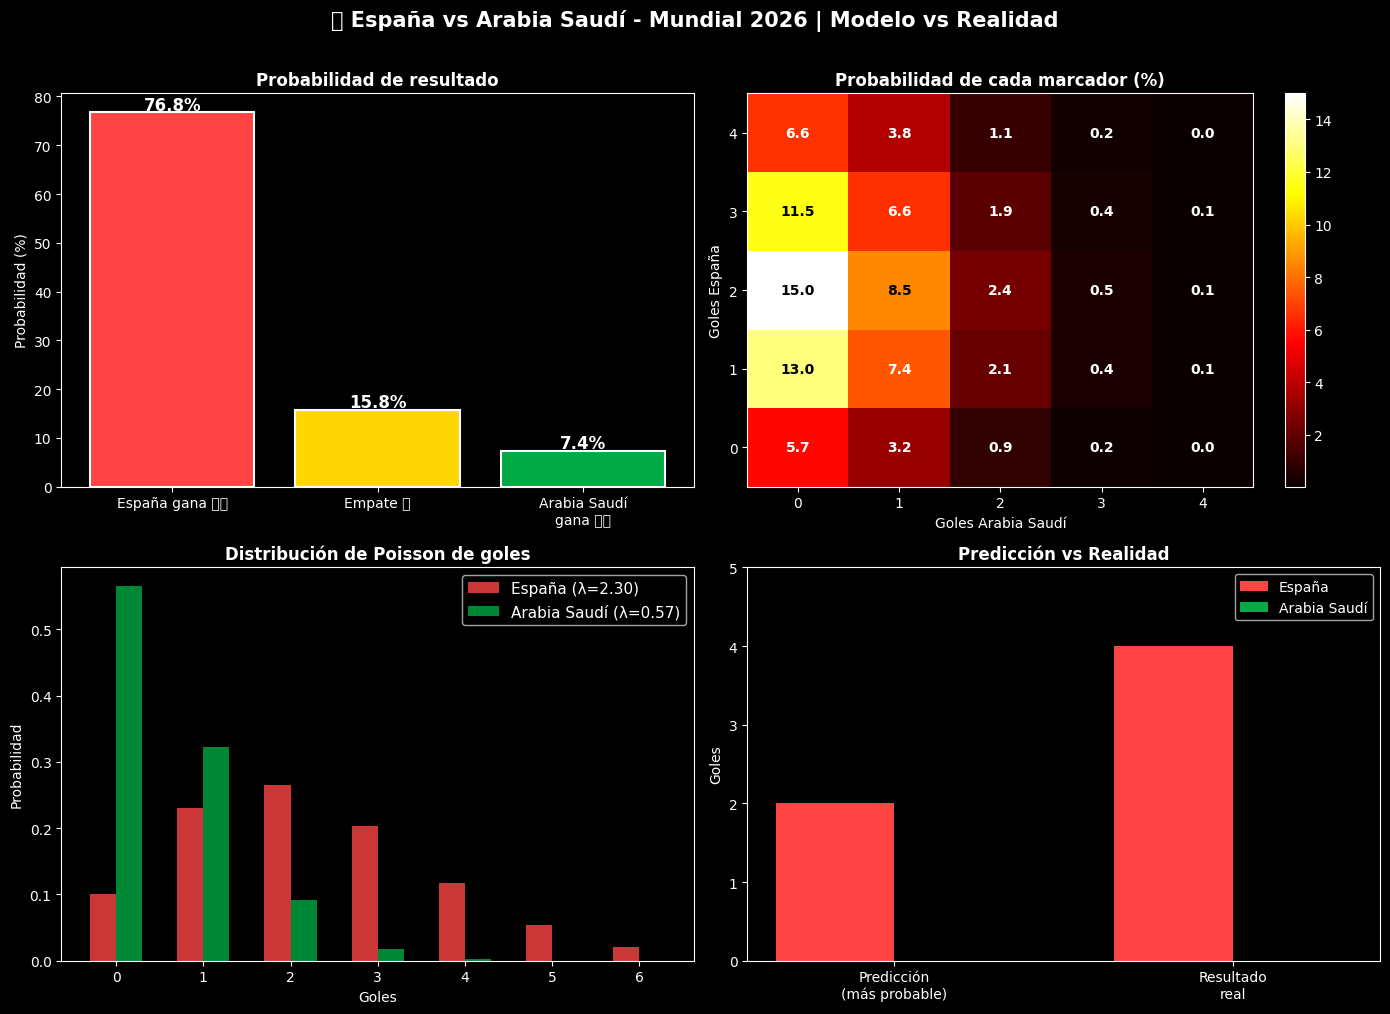

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Probabilidades de resultado
categorias = ['España gana 🇪🇸', 'Empate 🤝', 'Arabia Saudí\ngana 🇸🇦']
probabilidades = [prob_espana, prob_empate, prob_saudi]
colores = ['#FF4444', '#FFD700', '#00AA44']
bars = axes[0,0].bar(categorias, probabilidades, color=colores, edgecolor='white', linewidth=1.5)
axes[0,0].set_ylabel('Probabilidad (%)')
axes[0,0].set_title('Probabilidad de resultado', fontweight='bold')
for bar, prob in zip(bars, probabilidades):
    axes[0,0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                   f'{prob:.1f}%', ha='center', fontweight='bold', fontsize=12)

# 2. Heatmap de marcadores
im = axes[0,1].imshow(matriz_prob[:5,:5] * 100, cmap='hot', origin='lower', aspect='auto')
axes[0,1].set_xlabel('Goles Arabia Saudí')
axes[0,1].set_ylabel('Goles España')
axes[0,1].set_title('Probabilidad de cada marcador (%)', fontweight='bold')
axes[0,1].set_xticks(range(5))
axes[0,1].set_yticks(range(5))
for i in range(5):
    for j in range(5):
        color = 'black' if matriz_prob[i][j] * 100 > 8 else 'white'
        axes[0,1].text(j, i, f'{matriz_prob[i][j]*100:.1f}', ha='center', va='center',
                       fontsize=10, color=color, fontweight='bold')
plt.colorbar(im, ax=axes[0,1])

# 3. Distribución de goles
x_vals = np.arange(0, 7)
axes[1,0].bar(x_vals - 0.15, poisson.pmf(x_vals, lambda_spain_final), 0.3,
              color='#FF4444', label=f'España (λ={lambda_spain_final:.2f})', alpha=0.8)
axes[1,0].bar(x_vals + 0.15, poisson.pmf(x_vals, lambda_saudi_final), 0.3,
              color='#00AA44', label=f'Arabia Saudí (λ={lambda_saudi_final:.2f})', alpha=0.8)
axes[1,0].set_xlabel('Goles')
axes[1,0].set_ylabel('Probabilidad')
axes[1,0].set_title('Distribución de Poisson de goles', fontweight='bold')
axes[1,0].legend(fontsize=11)
axes[1,0].set_xticks(x_vals)

# 4. Comparativa resultado real vs predicción
labels_comp = ['Predicción\n(más probable)', 'Resultado\nreal']
spain_goals_comp = [resultados[0][0], 4]
rival_goals_comp = [resultados[0][1], 0]
x_comp = np.arange(len(labels_comp))
width = 0.35
axes[1,1].bar(x_comp - width/2, spain_goals_comp, width, color='#FF4444', label='España')
axes[1,1].bar(x_comp + width/2, rival_goals_comp, width, color='#00AA44', label='Arabia Saudí')
axes[1,1].set_xticks(x_comp)
axes[1,1].set_xticklabels(labels_comp)
axes[1,1].set_ylabel('Goles')
axes[1,1].set_title('Predicción vs Realidad', fontweight='bold')
axes[1,1].legend()
axes[1,1].set_ylim(0, 5)

plt.suptitle('🏆 España vs Arabia Saudí - Mundial 2026 | Modelo vs Realidad',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('prediccion_espana_arabia.png', dpi=150, bbox_inches='tight', facecolor='black')
plt.show()

## 🧠 Resumen: ¿Acertó el modelo?

In [10]:
# Resultado real: España 4-0 Arabia Saudí
resultado_real = (4, 0)
prob_real = matriz_prob[resultado_real[0]][resultado_real[1]] * 100

print('╔══════════════════════════════════════════════════════════════╗')
print('║   🏆 ESPAÑA vs ARABIA SAUDÍ - MODELO vs REALIDAD           ║')
print('╠══════════════════════════════════════════════════════════════╣')
print(f'║  🎯 Predicción del modelo: España {resultados[0][0]}-{resultados[0][1]} Arabia Saudí    ║')
print(f'║  ⚽ Resultado real:        España 4-0 Arabia Saudí         ║')
print('╠══════════════════════════════════════════════════════════════╣')
print(f'║  ✅ ¿Acertó el ganador? SÍ                                 ║')
print(f'║  ❌ ¿Acertó el marcador exacto? NO                         ║')
print(f'║  📊 Prob. del 4-0 según el modelo: {prob_real:.1f}%                  ║')
print(f'║  📊 Prob. victoria España (acertado): {prob_espana:.1f}%             ║')
print('╠══════════════════════════════════════════════════════════════╣')
print(f'║  📌 CONCLUSIÓN:                                            ║')
print(f'║  El modelo acertó que España ganaba cómoda, pero un 4-0    ║')
print(f'║  es un resultado extremo que Poisson sitúa en la cola de   ║')
print(f'║  la distribución. Lamine Yamal no es modelable. 🐐         ║')
print('╚══════════════════════════════════════════════════════════════╝')

╔══════════════════════════════════════════════════════════════╗
║   🏆 ESPAÑA vs ARABIA SAUDÍ - MODELO vs REALIDAD           ║
╠══════════════════════════════════════════════════════════════╣
║  🎯 Predicción del modelo: España 2-0 Arabia Saudí    ║
║  ⚽ Resultado real:        España 4-0 Arabia Saudí         ║
╠══════════════════════════════════════════════════════════════╣
║  ✅ ¿Acertó el ganador? SÍ                                 ║
║  ❌ ¿Acertó el marcador exacto? NO                         ║
║  📊 Prob. del 4-0 según el modelo: 6.6%                  ║
║  📊 Prob. victoria España (acertado): 76.8%             ║
╠══════════════════════════════════════════════════════════════╣
║  📌 CONCLUSIÓN:                                            ║
║  El modelo acertó que España ganaba cómoda, pero un 4-0    ║
║  es un resultado extremo que Poisson sitúa en la cola de   ║
║  la distribución. Lamine Yamal no es modelable. 🐐         ║
╚══════════════════════════════════════════════════════════════╝
